# Peminjaman buku kategori teknologi dan ilmu terapan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import altair as alt
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Reshape, GRU, Dense, Dropout, TimeDistributed
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from bayes_opt import BayesianOptimization
from itertools import product

Read Dataset

In [2]:
buku_600 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_600.csv')
buku_600['Bulan'] = pd.to_datetime(buku_600['Bulan'], format='%m/%y')

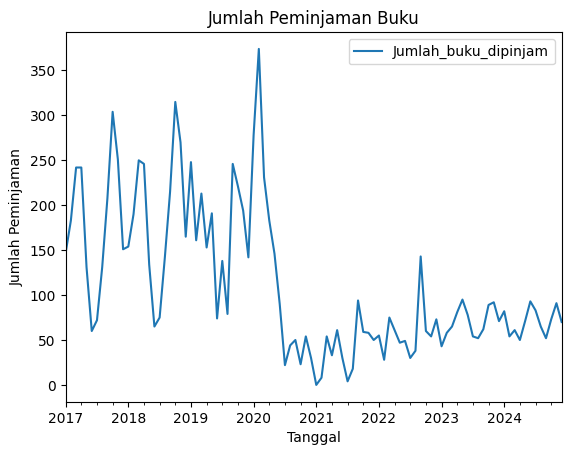

In [3]:
buku_600.plot(x='Bulan', y='Jumlah_buku_dipinjam', kind='line')
plt.title('Jumlah Peminjaman Buku')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Peminjaman')
plt.show()

IQR

        Bulan  Jumlah_buku_dipinjam
21 2018-10-01                   315
37 2020-02-01                   374
Batas bawah: -98.625
Batas atas: 308.375


Text(0, 0.5, 'Jumlah Buku')

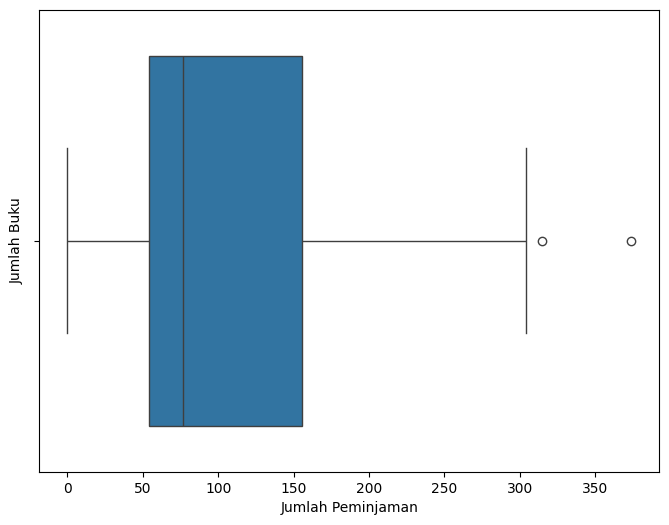

In [4]:
# Menghitung Q1, Q3 dan IQR
Q1 = buku_600['Jumlah_buku_dipinjam'].quantile(0.25)
Q3 = buku_600['Jumlah_buku_dipinjam'].quantile(0.75)
IQR = Q3 - Q1

# Batas bawah dan atas untuk outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
buku_600
outliers_000 = buku_600[(buku_600['Jumlah_buku_dipinjam'] < lower_bound) | (buku_600['Jumlah_buku_dipinjam'] > upper_bound)]

print(outliers_000)
# Menampilkan batas bawah dan atas
print(f"Batas bawah: {lower_bound}")
print(f"Batas atas: {upper_bound}")

plt.figure(figsize=(8, 6))
sns.boxplot(x=buku_600['Jumlah_buku_dipinjam'])
plt.xlabel('Jumlah Peminjaman')
plt.ylabel('Jumlah Buku')

Hyperparameter Tuning

In [5]:
# Rentang hyperparameter
window_sizes = [3, 8, 9]  # Contoh rentang window size
tolerances = [0.5, 1, 2, 2.5, 3]  # Contoh rentang tolerance

# Buat grid kombinasi hyperparameter
grid = list(product(window_sizes, tolerances))

# Simpan hasil tuning
results = []

for window_size, tolerance in grid:
    for tolerance in tolerances:
        buku_600_copy = buku_600.copy()  # Buat salinan data asli agar tidak merusak data asli

        # Rolling median dan rolling std
        buku_600_copy['rolling_median'] = buku_600_copy['Jumlah_buku_dipinjam'].rolling(window=window_size, center=True).median()
        buku_600_copy['rolling_std'] = buku_600_copy['Jumlah_buku_dipinjam'].rolling(window=window_size, center=True).std()

        # Batas atas dan bawah
        upper_bound = buku_600_copy['rolling_median'] + tolerance * buku_600_copy['rolling_std']
        lower_bound = buku_600_copy['rolling_median'] - tolerance * buku_600_copy['rolling_std']

        # Deteksi ou    tlier awal
        detected_outliers = (buku_600_copy['Jumlah_buku_dipinjam'] > upper_bound) | \
                            (buku_600_copy['Jumlah_buku_dipinjam'] < lower_bound)

        # Ganti outlier dengan rolling median
        buku_600_cleaned = buku_600_copy['Jumlah_buku_dipinjam'].copy()
        detected_outliers = (buku_600_copy['Jumlah_buku_dipinjam'] > upper_bound) | \
                            (buku_600_copy['Jumlah_buku_dipinjam'] < lower_bound)
        buku_600_cleaned[detected_outliers] = buku_600_copy['rolling_median'][detected_outliers]


        # Forecasting (contoh dummy prediksi)
        y_actual = buku_600_cleaned[10:]  # Data aktual (tes)
        y_pred = buku_600_cleaned.shift(1)[10:]  # Dummy prediksi

        # Hitung metrik evaluasi
        mape = mean_absolute_percentage_error(y_actual, y_pred)
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

        # Simpan hasil
        results.append({
            'window_size': window_size,
            'tolerance': tolerance,
            'mape': mape,
            'rmse': rmse
        })

# Analisis hasil
results_df = pd.DataFrame(results)
best_result = results_df.sort_values(by='rmse').iloc[0]
print("Kombinasi terbaik berdasarkan MAPE & RMSE: ")
print(best_result)
# Tampilkan semua hasil tuning dari grid search
print("\nSeluruh hasil kombinasi hyperparameter rolling window median:")
for res in results:
    print(f"window_size: {res['window_size']}, Tolerance: {res['tolerance']} -> RMSE: {res['rmse']:.3f}")
# Simpan hasil grid search ke file Excel
results_df.to_excel("rwm buku_600.xlsx", index=False)

C:\Users\asus\AppData\Local\Temp\ipykernel_16752\1748128980.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[157.  169.5 141.  152.5 172.  199.  227.  172.  152.5 166.  178.5 153.5
 190.  190.  214.  214.  202.  178.  157.  157.  172.  172.  166.5 168.
 226.  226.  207.5  70.   37.   26.5  31.5  31.5  31.5  24.   43.5  45.5
  54.   56.5  52.5  49.5  54.5  51.5  62.5  69.   61.5  63.5  71.5  79.5
  74.5  74.5  66.5  66.5  71.   71.   71.   63.   68.   72. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  buku_600_cleaned[detected_outliers] = buku_600_copy['rolling_median'][detected_outliers]
C:\Users\asus\AppData\Local\Temp\ipykernel_16752\1748128980.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[157.  169.5 152.5 172.  227.  172.  152.5 166.  178.5 190.  190.  157.
 172

Kombinasi terbaik berdasarkan MAPE & RMSE: 
window_size     8.000000
tolerance       0.500000
mape            0.127083
rmse           16.781860
Name: 25, dtype: float64

Seluruh hasil kombinasi hyperparameter rolling window median:
window_size: 3, Tolerance: 0.5 -> RMSE: 35.172
window_size: 3, Tolerance: 1 -> RMSE: 42.445
window_size: 3, Tolerance: 2 -> RMSE: 53.773
window_size: 3, Tolerance: 2.5 -> RMSE: 53.773
window_size: 3, Tolerance: 3 -> RMSE: 53.773
window_size: 3, Tolerance: 0.5 -> RMSE: 35.172
window_size: 3, Tolerance: 1 -> RMSE: 42.445
window_size: 3, Tolerance: 2 -> RMSE: 53.773
window_size: 3, Tolerance: 2.5 -> RMSE: 53.773
window_size: 3, Tolerance: 3 -> RMSE: 53.773
window_size: 3, Tolerance: 0.5 -> RMSE: 35.172
window_size: 3, Tolerance: 1 -> RMSE: 42.445
window_size: 3, Tolerance: 2 -> RMSE: 53.773
window_size: 3, Tolerance: 2.5 -> RMSE: 53.773
window_size: 3, Tolerance: 3 -> RMSE: 53.773
window_size: 3, Tolerance: 0.5 -> RMSE: 35.172
window_size: 3, Tolerance: 1 -> RM

Outlier handling Rolling Window Median

C:\Users\asus\AppData\Local\Temp\ipykernel_16752\2646038084.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[157.  169.5 141.  152.5 172.  199.  227.  172.  152.5 166.  178.5 153.5
 190.  190.  214.  214.  202.  178.  157.  157.  172.  172.  166.5 168.
 226.  226.  207.5  70.   37.   26.5  31.5  31.5  31.5  24.   43.5  45.5
  54.   56.5  52.5  49.5  54.5  51.5  62.5  69.   61.5  63.5  71.5  79.5
  74.5  74.5  66.5  66.5  71.   71.   71.   63.   68.   72. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  buku_600_copy.loc[detected_outliers, 'Jumlah_buku_dipinjam'] = buku_600_copy.loc[detected_outliers, 'rolling_median']


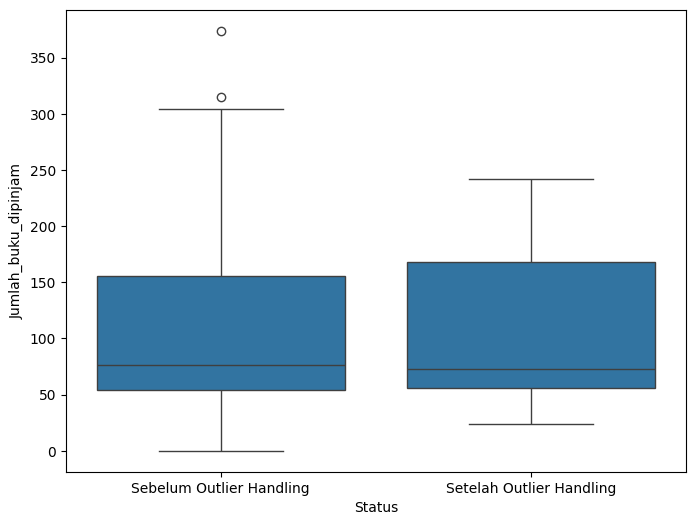

In [6]:
# Ambil kombinasi hyperparameter terbaik
best_window_size = 8
best_tolerance = 0.5

# Salin data asli
buku_600_copy = buku_600.copy()

# Rolling median dan rolling std
buku_600_copy['rolling_median'] = buku_600_copy['Jumlah_buku_dipinjam'].rolling(window=best_window_size, center=True).median()
buku_600_copy['rolling_std'] = buku_600_copy['Jumlah_buku_dipinjam'].rolling(window=best_window_size, center=True).std()

# Batas atas dan bawah
upper_bound = buku_600_copy['rolling_median'] + best_tolerance * buku_600_copy['rolling_std']
lower_bound = buku_600_copy['rolling_median'] - best_tolerance * buku_600_copy['rolling_std']

# Deteksi outlier awal
detected_outliers = (buku_600_copy['Jumlah_buku_dipinjam'] > upper_bound) | \
                    (buku_600_copy['Jumlah_buku_dipinjam'] < lower_bound)

# Ganti outlier dengan rolling median
buku_600_copy.loc[detected_outliers, 'Jumlah_buku_dipinjam'] = buku_600_copy.loc[detected_outliers, 'rolling_median']

# Buat DataFrame untuk visualisasi
buku_600_copy['Status'] = 'Setelah Outlier Handling'
buku_600['Status'] = 'Sebelum Outlier Handling'

df_visual = pd.concat([buku_600[['Jumlah_buku_dipinjam', 'Status']], 
                    buku_600_copy[['Jumlah_buku_dipinjam', 'Status']]])

# Plot Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Status', y='Jumlah_buku_dipinjam', data=df_visual)
plt.show()


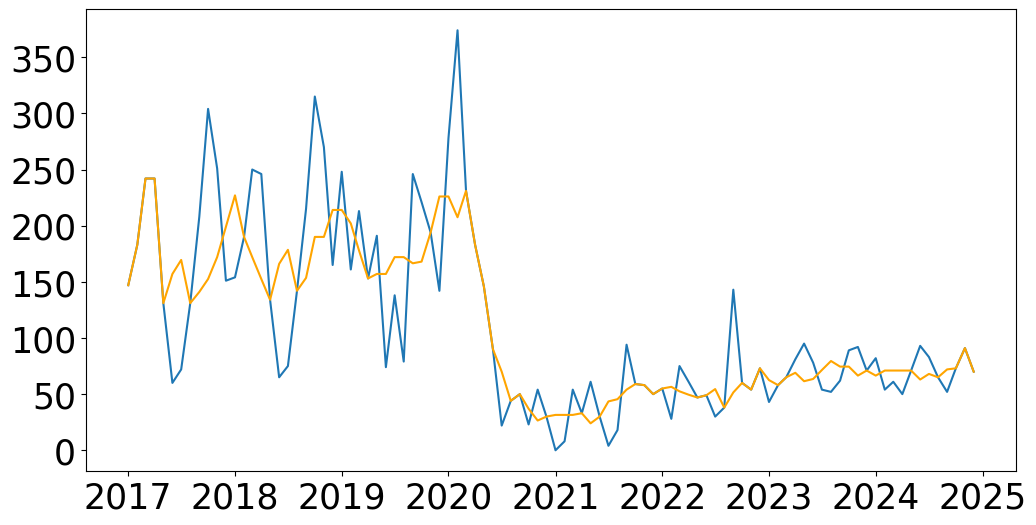

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(buku_600['Bulan'], buku_600['Jumlah_buku_dipinjam'], label='Sebelum Outlier Handling')
plt.plot(buku_600_copy['Bulan'], buku_600_copy['Jumlah_buku_dipinjam'], label='Setelah Outlier Handling', color='orange')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.show()

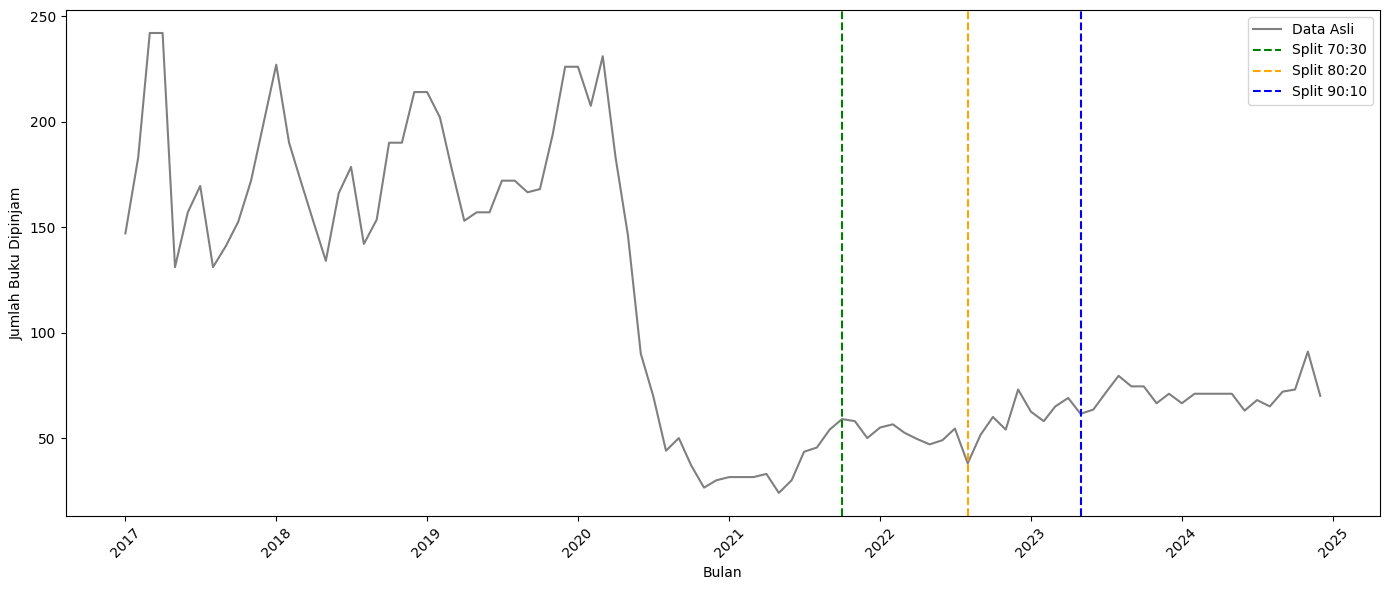

In [8]:
# Ambil data asli sebelum normalisasi untuk referensi
data_original = buku_600_copy[['Jumlah_buku_dipinjam']].values
bulan = buku_600_copy['Bulan'].values  # Ambil label bulan

# Ukuran figure
plt.figure(figsize=(14, 6))

# Daftar rasio split yang ingin ditampilkan
split_ratios = [0.6, 0.7, 0.8]
colors = ['green', 'orange', 'blue']
labels = ['70:30', '80:20', '90:10']

# Plot data original untuk semua bulan sebagai latar
plt.plot(bulan, data_original, label='Data Asli', color='black', alpha=0.5)

# Loop untuk setiap rasio split
for ratio, color, label in zip(split_ratios, colors, labels):
    split_idx = int(len(data_original) * ratio)
    data_train = data_original[:split_idx]
    data_test = data_original[split_idx:]

    bulan_train = bulan[:split_idx]
    bulan_test = bulan[split_idx:]

    # Plot garis split
    plt.axvline(x=bulan[split_idx], color=color, linestyle='--', label=f'Split {label}')

# Label dan tampilan
plt.xticks(rotation=45)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.tight_layout()
plt.show()


# Data split 60:40

Hyperparameter Tunning

In [9]:
# Data awal
X_raw = buku_600_copy[['Jumlah_buku_dipinjam']].values

# Fungsi membuat data dengan timestep
def create_timestep_data(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Grid Search Parameter
param_grid = {
    'timestep': [12, 24],
    'epochs': [50, 100, 170],
    'batch_size': [32, 64, 128],
    'gru_units': [10, 20, 100],
    'cnn_filters': [16, 32, 128],
}

# Inisialisasi variabel terbaik
best_rmse = float('inf')
best_params = None
results = []

# Iterasi seluruh kombinasi parameter
for params in ParameterGrid(param_grid):
    timestep = params['timestep']
    print(f"\nTesting combination: {params}")

    # Buat ulang data dengan timestep baru
    X, y = create_timestep_data(X_raw, timestep)

    # Split train-test (tanpa shuffle)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)

    # Reshape data agar sesuai dengan input model CNN-GRU
    X_train = X_train.reshape((X_train.shape[0], timestep, 1))
    X_test = X_test.reshape((X_test.shape[0], timestep, 1))

    # Normalisasi target
    scaler = MinMaxScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

    # Bangun model CNN-GRU
    model = Sequential()

    # CNN Layer
    model.add(Conv1D(filters=params['cnn_filters'], kernel_size=1, activation='relu', input_shape=(timestep, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())  

    # Reshape sebelum masuk ke GRU
    model.add(Reshape((1, -1)))

    # GRU Layer
    model.add(GRU(params['gru_units'], activation='relu'))  
    model.add(Dropout(0.2))  

    # Output Layer
    model.add(Dense(1))

    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train model
    model.fit(X_train, y_train_scaled, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    y_pred_inverse = scaler.inverse_transform(y_pred)
    y_test_inverse = scaler.inverse_transform(y_test_scaled)
    
    mse = mean_squared_error(y_test_inverse, y_pred_inverse)
    rmse = np.sqrt(mse)

    print(f"RMSE: {rmse}")

    # Simpan hasil tuning
    results.append((params, rmse))
    
    # Simpan kombinasi terbaik
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

# Print hasil terbaik
print(f"\nBest RMSE: {best_rmse}")
print(f"Best parameters: {best_params}")

# Display seluruh hasil tuning
for res in results:
    print(f"Params: {res[0]} -> RMSE: {res[1]}")

# Simpan hasil tuning ke Excel
results_df = pd.DataFrame([
    {
        'timestep': r[0]['timestep'],
        'epochs': r[0]['epochs'],
        'batch_size': r[0]['batch_size'],
        'gru_units': r[0]['gru_units'],
        'cnn_filters': r[0]['cnn_filters'],
        'RMSE': r[1]
    }
    for r in results
])

# Simpan ke file Excel
results_df.to_excel("tuning buku_600 60,40.xlsx", index=False)


Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
RMSE: 62.848867484677235

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
RMSE: 119.28892669335295

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12}


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
RMSE: 38.51126816370095

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
RMSE: 9.781638354644725

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
RMSE: 9.692999279894291

Best RMSE: 8.014378671389244
Best parameters: {'batch_size': 64, 'cnn_filters': 16, 'epochs': 170, 'gru_units': 10, 'timestep': 12}
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12} -> RMSE: 62.848867484677235
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24} -> RMSE: 119.28892669335295
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12} -> RMSE: 43.59167777808967
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 24} -> RMSE: 50.13538094029864
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 12} -> RMSE: 40.927166626236016
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 24} -> RMSE: 50.46963414373323
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 100, 'gru_units': 10, '

Model CNN-GRU

Epoch 1/170


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3115
Epoch 2/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.3036
Epoch 3/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.2970
Epoch 4/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2933
Epoch 5/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.2866
Epoch 6/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.2865
Epoch 7/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.2776
Epoch 8/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.2667
Epoch 9/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.2679
Epoch 10/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2635
Epoch 11/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.2544
Epoch 12/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.2488
Epoch 13/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.2428
Epoch 14/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2246
Epoch 15/170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2291
Epoch 16/170
1/1 ━━━━━━━━━━━━━━━

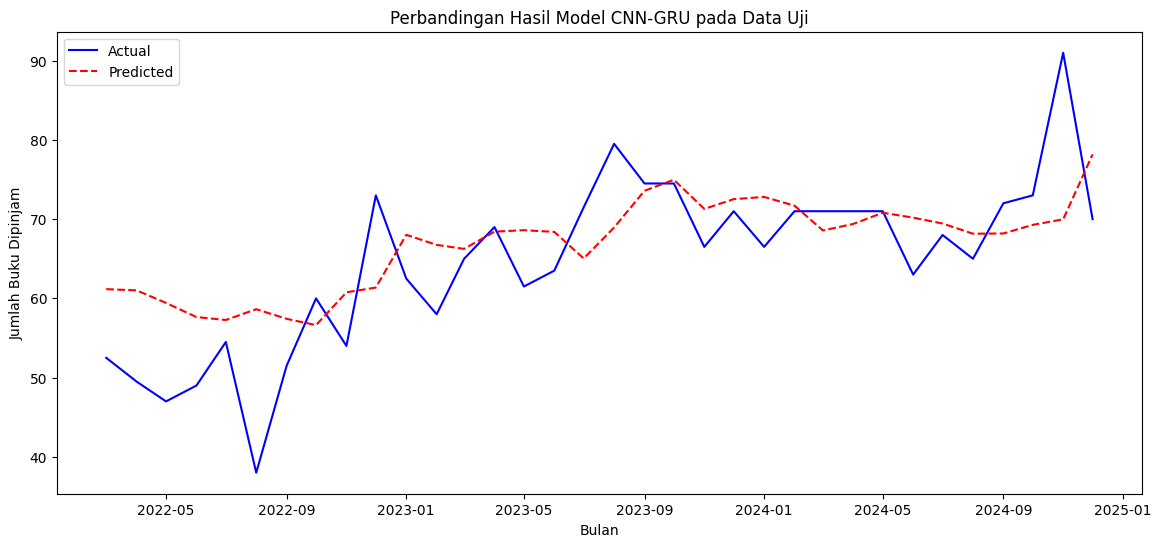

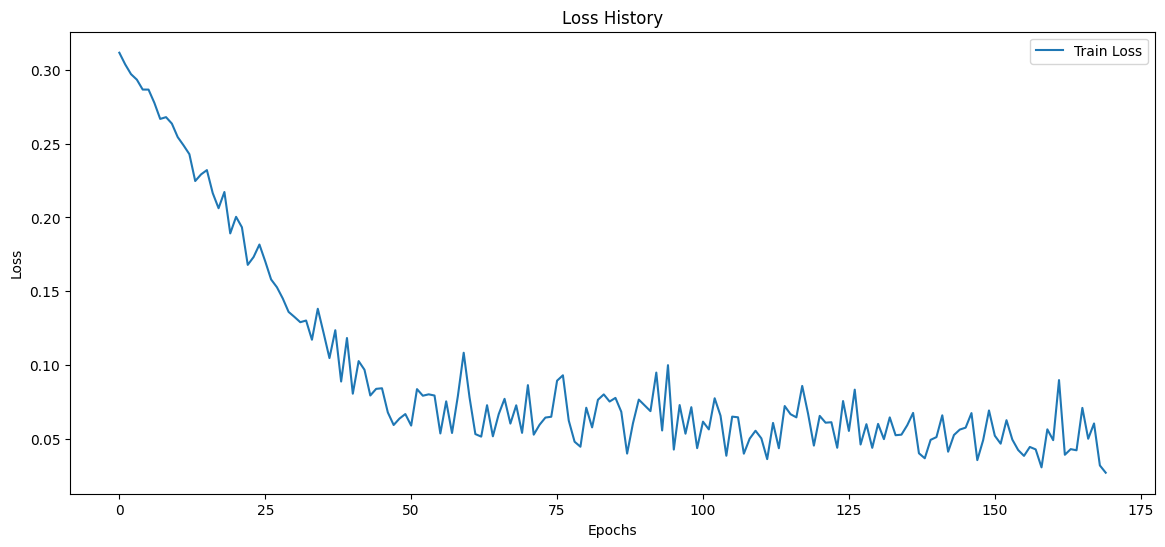

In [10]:
# Parameter window size
timestep = 12  # Menggunakan 6 bulan terakhir sebagai input

# Membentuk data input dengan sliding window
def create_sliding_window(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Memisahkan fitur dan target
X = buku_600_copy[['Jumlah_buku_dipinjam']].values
y = buku_600_copy[['Jumlah_buku_dipinjam']].values

# Normalisasi data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Membuat dataset sliding window
X_window, y_window = create_sliding_window(X_scaled, timestep)

# Split data menjadi train dan test (80% training, 20% testing)
split_idx = int(len(X_window) * 0.6)
X_train, X_test = X_window[:split_idx], X_window[split_idx:]
y_train, y_test = y_window[:split_idx], y_window[split_idx:]

# Reshape input menjadi tiga dimensi (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Membangun Model CNN-GRU
model_cnn_gru = Sequential()

# Lapisan CNN
model_cnn_gru.add(Conv1D(filters=16, kernel_size=1, activation='relu', input_shape=(timestep, 1)))
model_cnn_gru.add(MaxPooling1D(pool_size=2))
model_cnn_gru.add(Flatten())

# Ubah kembali ke bentuk tiga dimensi untuk input ke GRU
model_cnn_gru.add(Reshape((1, -1)))

# Lapisan GRU setelah CNN
model_cnn_gru.add(GRU(10, activation='relu'))
model_cnn_gru.add(Dropout(0.2))

# Lapisan output
model_cnn_gru.add(Dense(1))

# Kompilasi model
model_cnn_gru.compile(optimizer='adam', loss='mean_squared_error')

# Latih model
history_model = model_cnn_gru.fit(X_train, y_train, epochs=170, batch_size=64)

# Prediksi pada data uji
y_pred_cnn_gru = model_cnn_gru.predict(X_test)

# Konversi kembali ke skala asli
y_pred_cnn_gru_inverse = scaler.inverse_transform(y_pred_cnn_gru)
y_test_inverse = scaler.inverse_transform(y_test)

# Evaluasi model
mse = mean_squared_error(y_test_inverse, y_pred_cnn_gru_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_cnn_gru_inverse) * 100
mae = mean_absolute_error(y_test_inverse, y_pred_cnn_gru_inverse)

print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

# Plot hasil model (data aktual vs prediksi)
plt.figure(figsize=(14, 6))
plt.plot(buku_600_copy['Bulan'][-len(y_test_inverse):], y_test_inverse, label='Actual', color='blue')
plt.plot(buku_600_copy['Bulan'][-len(y_pred_cnn_gru_inverse):], y_pred_cnn_gru_inverse, label='Predicted', linestyle='--', color='red')
plt.title('Perbandingan Hasil Model CNN-GRU pada Data Uji')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()

# plot loss
plt.figure(figsize=(14, 6))
plt.plot(history_model.history['loss'], label='Train Loss')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediksi dalam skala normalisasi:
[[0.2494632 ]
 [0.24578533]
 [0.24635568]
 [0.23939472]
 [0.23886836]
 [0.22160614]
 [0.2218605 ]
 [0.22659674]
 [0.22817963]
 [0.21225977]
 [0.21319312]
 [0.2100136 ]]
Prediksi dalam skala asli:
[[78]
 [77]
 [77]
 [76]
 [76]
 [72]
 [72]
 [73]
 [73]
 [70]
 [70]
 [69]]
Hasil prediksi dalam DataFrame:
        Bulan  Prediksi
0  2024-12-31        78
1  2025-01-31        77
2  2025-02-28        77
3  2025-03-31        76
4  2025-04-30        76
5  2025-05-31        72
6  2025-06-30        72
7  2025-07-31    

C:\Users\asus\AppData\Local\Temp\ipykernel_23404\1971161598.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=buku_600_copy['Bulan'].values[-1], periods=12, freq='M')


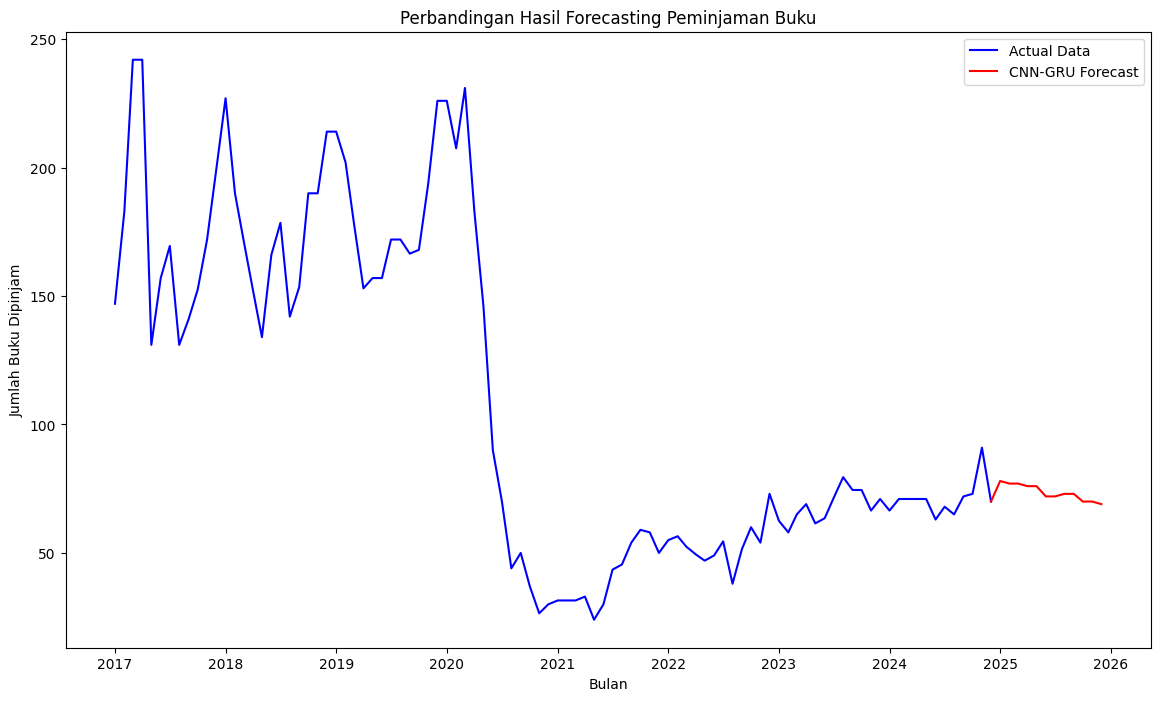

In [11]:
# Prediksi 12 bulan ke depan menggunakan sliding window
def predict_future(model, last_input, months=12):
    future_predictions = []
    current_input = last_input.copy()

    for _ in range(months):
        prediction = model.predict(current_input.reshape((1, timestep, 1)))
        future_predictions.append(prediction[0, 0])
        
        # Geser input window dengan menambahkan prediksi terbaru
        current_input = np.roll(current_input, -1)
        current_input[-1] = prediction[0, 0]

    return np.array(future_predictions).reshape(-1, 1)

# Gunakan data terakhir sebagai input awal
last_input = X_scaled[-timestep:]
future_preds_scaled = predict_future(model_cnn_gru, last_input, months=12)

# Cek nilai sebelum inverse transform
print("Prediksi dalam skala normalisasi:")
print(future_preds_scaled)

# Konversi kembali ke skala asli
future_preds = scaler.inverse_transform(future_preds_scaled)

# Konversi kembali ke skala asli dan ubah ke bilangan bulat
future_preds = scaler.inverse_transform(future_preds_scaled).astype(int)

# Cek nilai setelah inverse transform
print("Prediksi dalam skala asli:")
print(future_preds)

# Buat label bulan untuk prediksi
future_dates = pd.date_range(start=buku_600_copy['Bulan'].values[-1], periods=12, freq='M')

# Simpan hasil prediksi dalam DataFrame untuk analisis lebih lanjut
predictions_df = pd.DataFrame({'Bulan': future_dates, 'Prediksi': future_preds.flatten()})
print("Hasil prediksi dalam DataFrame:")
print(predictions_df)

# Gabungkan data aktual dan prediksi
combined_dates = np.concatenate([buku_600_copy['Bulan'].values, future_dates])
combined_values = np.concatenate([buku_600_copy['Jumlah_buku_dipinjam'].values, future_preds.flatten()])

# Visualisasi hasil prediksi dengan satu garis tetapi warna berbeda
plt.figure(figsize=(14, 8))

# Plot data aktual dengan warna biru
plt.plot(combined_dates[:len(buku_600_copy)], combined_values[:len(buku_600_copy)], color='blue', label='Actual Data')

# Plot data prediksi dengan warna merah (melanjutkan garis sebelumnya)
plt.plot(combined_dates[len(buku_600_copy)-1:], combined_values[len(buku_600_copy)-1:], color='red', label='CNN-GRU Forecast')

plt.title('Perbandingan Hasil Forecasting Peminjaman Buku')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()


# Data split 70:30

Hyperparameter Tunning

In [12]:
# Data awal
X_raw = buku_600_copy[['Jumlah_buku_dipinjam']].values

# Fungsi membuat data dengan timestep
def create_timestep_data(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Grid Search Parameter
param_grid = {
    'timestep': [12, 24],
    'epochs': [50, 100, 170],
    'batch_size': [32, 64, 128],
    'gru_units': [10, 20, 100],
    'cnn_filters': [16, 32, 128],
}

# Inisialisasi variabel terbaik
best_rmse = float('inf')
best_params = None
results = []

# Iterasi seluruh kombinasi parameter
for params in ParameterGrid(param_grid):
    timestep = params['timestep']
    print(f"\nTesting combination: {params}")

    # Buat ulang data dengan timestep baru
    X, y = create_timestep_data(X_raw, timestep)

    # Split train-test (tanpa shuffle)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

    # Reshape data agar sesuai dengan input model CNN-GRU
    X_train = X_train.reshape((X_train.shape[0], timestep, 1))
    X_test = X_test.reshape((X_test.shape[0], timestep, 1))

    # Normalisasi target
    scaler = MinMaxScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

    # Bangun model CNN-GRU
    model = Sequential()

    # CNN Layer
    model.add(Conv1D(filters=params['cnn_filters'], kernel_size=1, activation='relu', input_shape=(timestep, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())  

    # Reshape sebelum masuk ke GRU
    model.add(Reshape((1, -1)))

    # GRU Layer
    model.add(GRU(params['gru_units'], activation='relu'))  
    model.add(Dropout(0.2))  

    # Output Layer
    model.add(Dense(1))

    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train model
    model.fit(X_train, y_train_scaled, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    y_pred_inverse = scaler.inverse_transform(y_pred)
    y_test_inverse = scaler.inverse_transform(y_test_scaled)
    
    mse = mean_squared_error(y_test_inverse, y_pred_inverse)
    rmse = np.sqrt(mse)

    print(f"RMSE: {rmse}")

    # Simpan hasil tuning
    results.append((params, rmse))
    
    # Simpan kombinasi terbaik
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

# Print hasil terbaik
print(f"\nBest RMSE: {best_rmse}")
print(f"Best parameters: {best_params}")

# Display seluruh hasil tuning
for res in results:
    print(f"Params: {res[0]} -> RMSE: {res[1]}")

# Simpan hasil tuning ke Excel
results_df = pd.DataFrame([
    {
        'timestep': r[0]['timestep'],
        'epochs': r[0]['epochs'],
        'batch_size': r[0]['batch_size'],
        'gru_units': r[0]['gru_units'],
        'cnn_filters': r[0]['cnn_filters'],
        'RMSE': r[1]
    }
    for r in results
])

# Simpan ke file Excel
results_df.to_excel("tuning buku_600 70,30.xlsx", index=False)


Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
RMSE: 39.314571033900826

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
RMSE: 43.79355389882546

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12}


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
RMSE: 41.886328535089085

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
RMSE: 7.234479276653285

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
RMSE: 39.62093177811244

Best RMSE: 6.850903700673859
Best parameters: {'batch_size': 64, 'cnn_filters': 32, 'epochs': 100, 'gru_units': 10, 'timestep': 24}
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12} -> RMSE: 39.314571033900826
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24} -> RMSE: 43.79355389882546
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12} -> RMSE: 93.03520439019965
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 24} -> RMSE: 533.2528719295284
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 12} -> RMSE: 25.72754231351691
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 24} -> RMSE: 35.31690403795328
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 100, 'gru_units': 10, 'ti

Model CNN-GRU

Epoch 1/100


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.2431
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.2205
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.2006
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.1835
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1657
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1448
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1415
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1191
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1130
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1010
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0913
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0829
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0888
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0869
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0746
Epoch 16/100
1/1 ━━━━━━━━━━━━━━━━

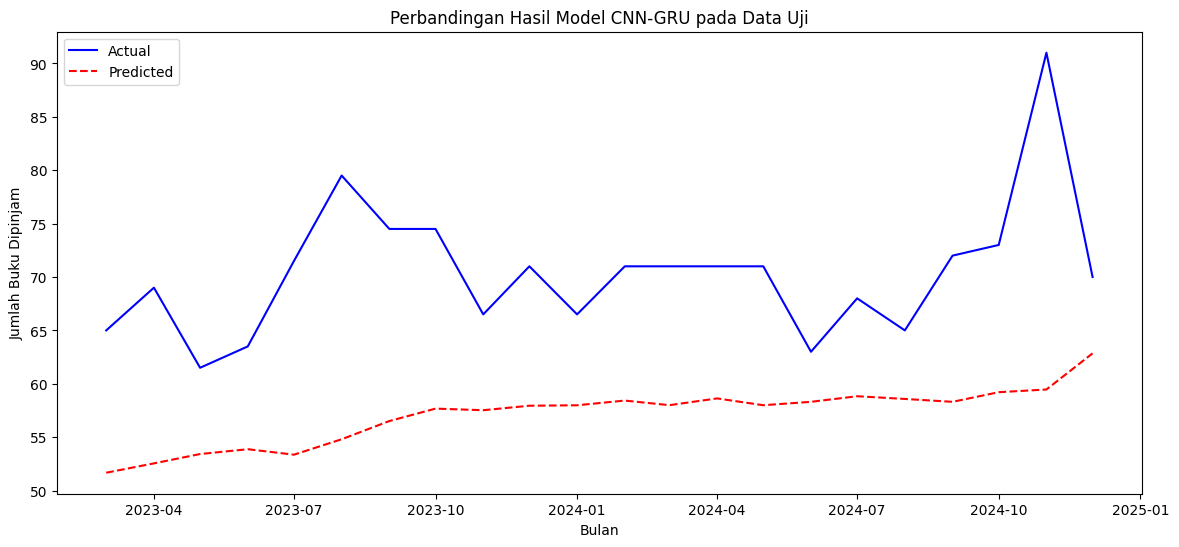

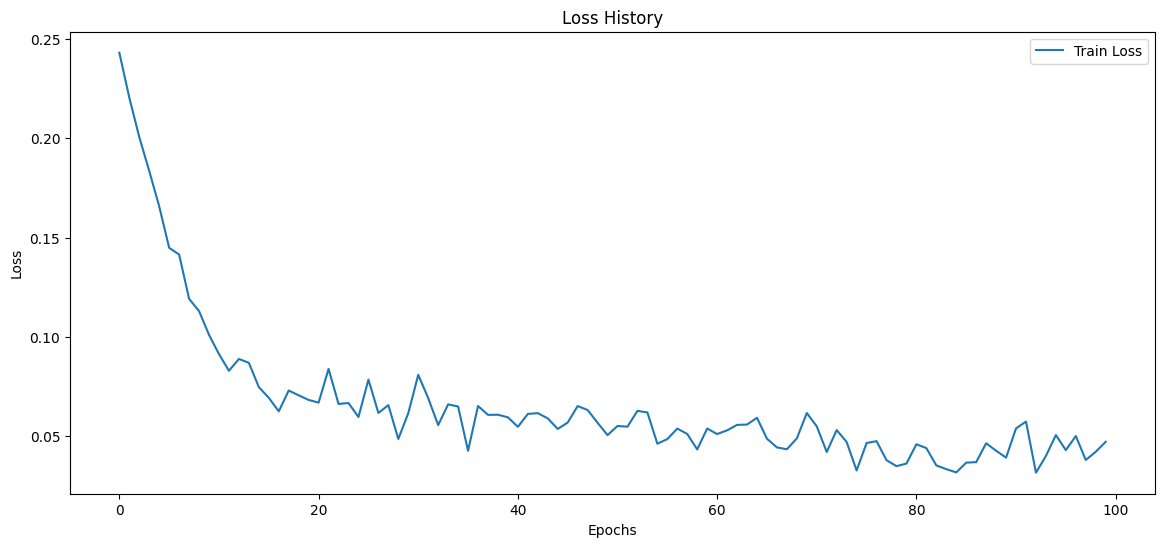

In [13]:
# Parameter window size
timestep = 24  # Menggunakan 6 bulan terakhir sebagai input

# Membentuk data input dengan sliding window
def create_sliding_window(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Memisahkan fitur dan target
X = buku_600_copy[['Jumlah_buku_dipinjam']].values
y = buku_600_copy[['Jumlah_buku_dipinjam']].values

# Normalisasi data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Membuat dataset sliding window
X_window, y_window = create_sliding_window(X_scaled, timestep)

# Split data menjadi train dan test (80% training, 20% testing)
split_idx = int(len(X_window) * 0.7)
X_train, X_test = X_window[:split_idx], X_window[split_idx:]
y_train, y_test = y_window[:split_idx], y_window[split_idx:]

# Reshape input menjadi tiga dimensi (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Membangun Model CNN-GRU
model_cnn_gru = Sequential()

# Lapisan CNN
model_cnn_gru.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(timestep, 1)))
model_cnn_gru.add(MaxPooling1D(pool_size=2))
model_cnn_gru.add(Flatten())

# Ubah kembali ke bentuk tiga dimensi untuk input ke GRU
model_cnn_gru.add(Reshape((1, -1)))

# Lapisan GRU setelah CNN
model_cnn_gru.add(GRU(10, activation='relu'))
model_cnn_gru.add(Dropout(0.2))

# Lapisan output
model_cnn_gru.add(Dense(1))

# Kompilasi model
model_cnn_gru.compile(optimizer='adam', loss='mean_squared_error')

# Latih model
history_model = model_cnn_gru.fit(X_train, y_train, epochs=100, batch_size=64)

# Prediksi pada data uji
y_pred_cnn_gru = model_cnn_gru.predict(X_test)

# Konversi kembali ke skala asli
y_pred_cnn_gru_inverse = scaler.inverse_transform(y_pred_cnn_gru)
y_test_inverse = scaler.inverse_transform(y_test)

# Evaluasi model
mse = mean_squared_error(y_test_inverse, y_pred_cnn_gru_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_cnn_gru_inverse) * 100
mae = mean_absolute_error(y_test_inverse, y_pred_cnn_gru_inverse)

print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

# Plot hasil model (data aktual vs prediksi)
plt.figure(figsize=(14, 6))
plt.plot(buku_600_copy['Bulan'][-len(y_test_inverse):], y_test_inverse, label='Actual', color='blue')
plt.plot(buku_600_copy['Bulan'][-len(y_pred_cnn_gru_inverse):], y_pred_cnn_gru_inverse, label='Predicted', linestyle='--', color='red')
plt.title('Perbandingan Hasil Model CNN-GRU pada Data Uji')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()

# plot loss
plt.figure(figsize=(14, 6))
plt.plot(history_model.history['loss'], label='Train Loss')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Prediksi dalam skala normalisasi:
[[0.1760497 ]
 [0.17016219]
 [0.16377342]
 [0.15898666]
 [0.15479313]
 [0.1484392 ]
 [0.14230898]
 [0.1396256 ]
 [0.1354782 ]
 [0.12788099]
 [0.12356501]
 [0.12224597]]
Prediksi dalam skala asli:
[[62]
 [61]
 [59]
 [58]
 [57]
 [56]
 [55]
 [54]
 [53]
 [51]
 [50]
 [50]]
Hasil prediksi dalam DataFrame:
        Bulan  Prediksi
0  2024-12-31        62
1  2025-01-31        61
2  2025-02-28        59
3  2025-03-31        58
4  2025-04-30        57
5  2025-05-31        56
6  2025-06-30        55
7  2025-07-31   

C:\Users\asus\AppData\Local\Temp\ipykernel_23404\1971161598.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=buku_600_copy['Bulan'].values[-1], periods=12, freq='M')


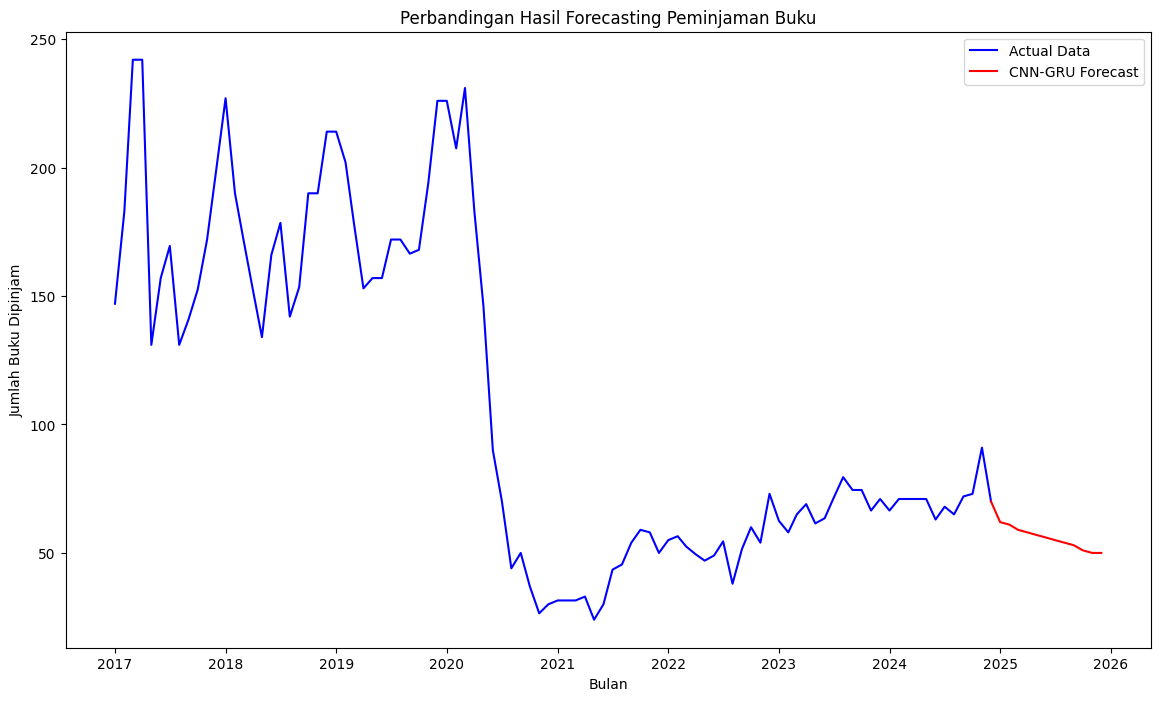

In [14]:
# Prediksi 12 bulan ke depan menggunakan sliding window
def predict_future(model, last_input, months=12):
    future_predictions = []
    current_input = last_input.copy()

    for _ in range(months):
        prediction = model.predict(current_input.reshape((1, timestep, 1)))
        future_predictions.append(prediction[0, 0])
        
        # Geser input window dengan menambahkan prediksi terbaru
        current_input = np.roll(current_input, -1)
        current_input[-1] = prediction[0, 0]

    return np.array(future_predictions).reshape(-1, 1)

# Gunakan data terakhir sebagai input awal
last_input = X_scaled[-timestep:]
future_preds_scaled = predict_future(model_cnn_gru, last_input, months=12)

# Cek nilai sebelum inverse transform
print("Prediksi dalam skala normalisasi:")
print(future_preds_scaled)

# Konversi kembali ke skala asli
future_preds = scaler.inverse_transform(future_preds_scaled)

# Konversi kembali ke skala asli dan ubah ke bilangan bulat
future_preds = scaler.inverse_transform(future_preds_scaled).astype(int)

# Cek nilai setelah inverse transform
print("Prediksi dalam skala asli:")
print(future_preds)

# Buat label bulan untuk prediksi
future_dates = pd.date_range(start=buku_600_copy['Bulan'].values[-1], periods=12, freq='M')

# Simpan hasil prediksi dalam DataFrame untuk analisis lebih lanjut
predictions_df = pd.DataFrame({'Bulan': future_dates, 'Prediksi': future_preds.flatten()})
print("Hasil prediksi dalam DataFrame:")
print(predictions_df)

# Gabungkan data aktual dan prediksi
combined_dates = np.concatenate([buku_600_copy['Bulan'].values, future_dates])
combined_values = np.concatenate([buku_600_copy['Jumlah_buku_dipinjam'].values, future_preds.flatten()])

# Visualisasi hasil prediksi dengan satu garis tetapi warna berbeda
plt.figure(figsize=(14, 8))

# Plot data aktual dengan warna biru
plt.plot(combined_dates[:len(buku_600_copy)], combined_values[:len(buku_600_copy)], color='blue', label='Actual Data')

# Plot data prediksi dengan warna merah (melanjutkan garis sebelumnya)
plt.plot(combined_dates[len(buku_600_copy)-1:], combined_values[len(buku_600_copy)-1:], color='red', label='CNN-GRU Forecast')

plt.title('Perbandingan Hasil Forecasting Peminjaman Buku')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()


# Data split 80:20

Hyperparameter Tunning

In [15]:
# Data awal
X_raw = buku_600_copy[['Jumlah_buku_dipinjam']].values

# Fungsi membuat data dengan timestep
def create_timestep_data(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Grid Search Parameter
param_grid = {
    'timestep': [12, 24],
    'epochs': [50, 100, 170],
    'batch_size': [32, 64, 128],
    'gru_units': [10, 20, 100],
    'cnn_filters': [16, 32, 128],
}

# Inisialisasi variabel terbaik
best_rmse = float('inf')
best_params = None
results = []

# Iterasi seluruh kombinasi parameter
for params in ParameterGrid(param_grid):
    timestep = params['timestep']
    print(f"\nTesting combination: {params}")

    # Buat ulang data dengan timestep baru
    X, y = create_timestep_data(X_raw, timestep)

    # Split train-test (tanpa shuffle)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Reshape data agar sesuai dengan input model CNN-GRU
    X_train = X_train.reshape((X_train.shape[0], timestep, 1))
    X_test = X_test.reshape((X_test.shape[0], timestep, 1))

    # Normalisasi target
    scaler = MinMaxScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

    # Bangun model CNN-GRU
    model = Sequential()

    # CNN Layer
    model.add(Conv1D(filters=params['cnn_filters'], kernel_size=1, activation='relu', input_shape=(timestep, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())  

    # Reshape sebelum masuk ke GRU
    model.add(Reshape((1, -1)))

    # GRU Layer
    model.add(GRU(params['gru_units'], activation='relu'))  
    model.add(Dropout(0.2))  

    # Output Layer
    model.add(Dense(1))

    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train model
    model.fit(X_train, y_train_scaled, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    y_pred_inverse = scaler.inverse_transform(y_pred)
    y_test_inverse = scaler.inverse_transform(y_test_scaled)
    
    mse = mean_squared_error(y_test_inverse, y_pred_inverse)
    rmse = np.sqrt(mse)

    print(f"RMSE: {rmse}")

    # Simpan hasil tuning
    results.append((params, rmse))
    
    # Simpan kombinasi terbaik
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

# Print hasil terbaik
print(f"\nBest RMSE: {best_rmse}")
print(f"Best parameters: {best_params}")

# Display seluruh hasil tuning
for res in results:
    print(f"Params: {res[0]} -> RMSE: {res[1]}")

# Simpan hasil tuning ke Excel
results_df = pd.DataFrame([
    {
        'timestep': r[0]['timestep'],
        'epochs': r[0]['epochs'],
        'batch_size': r[0]['batch_size'],
        'gru_units': r[0]['gru_units'],
        'cnn_filters': r[0]['cnn_filters'],
        'RMSE': r[1]
    }
    for r in results
])

# Simpan ke file Excel
results_df.to_excel("tuning buku_600 80,20.xlsx", index=False)


Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
RMSE: 35.545251507719776

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
RMSE: 36.699746072320345

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12}


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
RMSE: 38.06423110206846

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
RMSE: 7.927353288811878

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
RMSE: 16.23049170240703

Best RMSE: 6.386900453939706
Best parameters: {'batch_size': 32, 'cnn_filters': 128, 'epochs': 100, 'gru_units': 10, 'timestep': 12}
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12} -> RMSE: 35.545251507719776
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24} -> RMSE: 36.699746072320345
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12} -> RMSE: 12.790650549555263
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 24} -> RMSE: 55.52379317477445
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 12} -> RMSE: 22.457361316143686
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 24} -> RMSE: 19.43053289241437
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 100, 'gru_units': 10,

Model CNN-GRU

Epoch 1/100


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.2162
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2063
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1913
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1602
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1414
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1039
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1145
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0744
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0550
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0695
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0694
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0669
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0606
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0661
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0441
Epoch 16/100
3/3 ━━━━━━━━━━━━━━

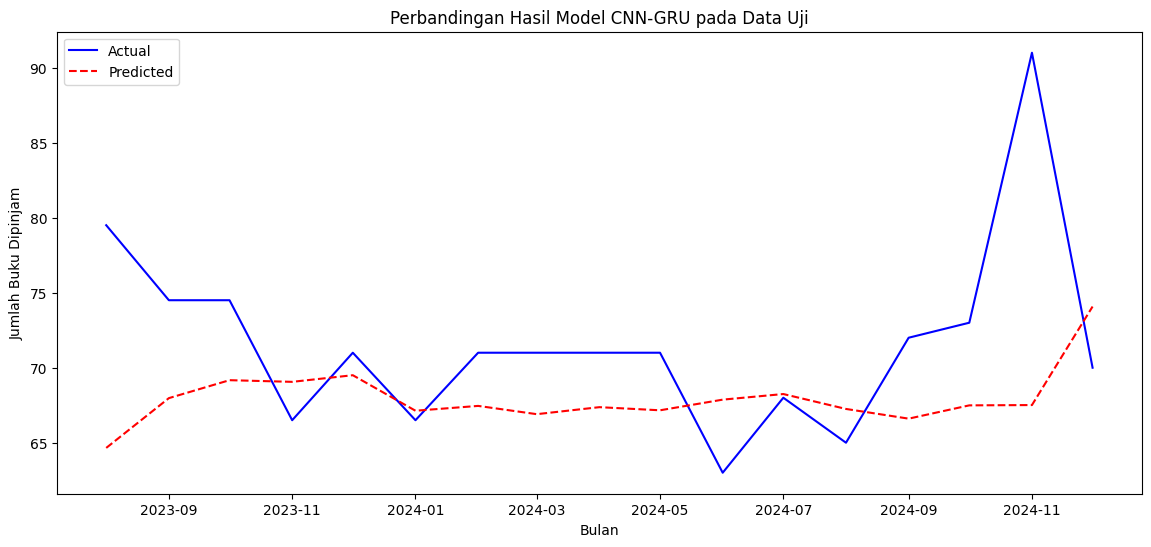

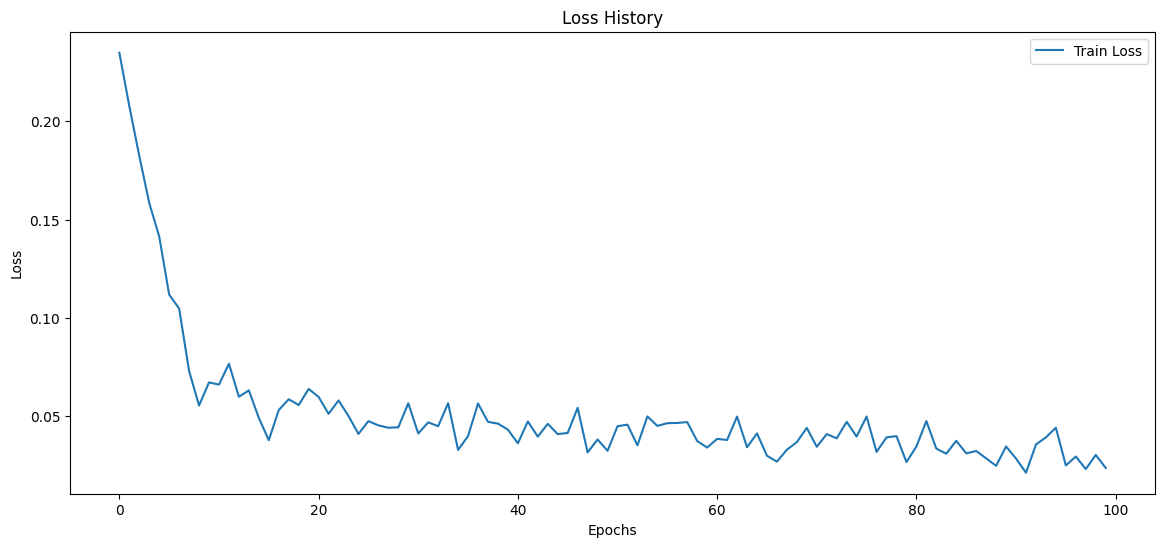

In [16]:
# Parameter window size
timestep = 12  # Menggunakan 6 bulan terakhir sebagai input

# Membentuk data input dengan sliding window
def create_sliding_window(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Memisahkan fitur dan target
X = buku_600_copy[['Jumlah_buku_dipinjam']].values
y = buku_600_copy[['Jumlah_buku_dipinjam']].values

# Normalisasi data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Membuat dataset sliding window
X_window, y_window = create_sliding_window(X_scaled, timestep)

# Split data menjadi train dan test (80% training, 20% testing)
split_idx = int(len(X_window) * 0.8)
X_train, X_test = X_window[:split_idx], X_window[split_idx:]
y_train, y_test = y_window[:split_idx], y_window[split_idx:]

# Reshape input menjadi tiga dimensi (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Membangun Model CNN-GRU
model_cnn_gru = Sequential()

# Lapisan CNN
model_cnn_gru.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(timestep, 1)))
model_cnn_gru.add(MaxPooling1D(pool_size=2))
model_cnn_gru.add(Flatten())

# Ubah kembali ke bentuk tiga dimensi untuk input ke GRU
model_cnn_gru.add(Reshape((1, -1)))

# Lapisan GRU setelah CNN
model_cnn_gru.add(GRU(10, activation='relu'))
model_cnn_gru.add(Dropout(0.2))

# Lapisan output
model_cnn_gru.add(Dense(1))

# Kompilasi model
model_cnn_gru.compile(optimizer='adam', loss='mean_squared_error')

# Latih model
history_model = model_cnn_gru.fit(X_train, y_train, epochs=100, batch_size=32)

# Prediksi pada data uji
y_pred_cnn_gru = model_cnn_gru.predict(X_test)

# Konversi kembali ke skala asli
y_pred_cnn_gru_inverse = scaler.inverse_transform(y_pred_cnn_gru)
y_test_inverse = scaler.inverse_transform(y_test)

# Evaluasi model
mse = mean_squared_error(y_test_inverse, y_pred_cnn_gru_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_cnn_gru_inverse) * 100
mae = mean_absolute_error(y_test_inverse, y_pred_cnn_gru_inverse)

print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

# Plot hasil model (data aktual vs prediksi)
plt.figure(figsize=(14, 6))
plt.plot(buku_600_copy['Bulan'][-len(y_test_inverse):], y_test_inverse, label='Actual', color='blue')
plt.plot(buku_600_copy['Bulan'][-len(y_pred_cnn_gru_inverse):], y_pred_cnn_gru_inverse, label='Predicted', linestyle='--', color='red')
plt.title('Perbandingan Hasil Model CNN-GRU pada Data Uji')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()

# plot loss
plt.figure(figsize=(14, 6))
plt.plot(history_model.history['loss'], label='Train Loss')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediksi dalam skala normalisasi:
[[0.23041633]
 [0.21693987]
 [0.21711254]
 [0.20379949]
 [0.20385838]
 [0.19564766]
 [0.1959154 ]
 [0.19501182]
 [0.19491452]
 [0.18947384]
 [0.1894241 ]
 [0.1875965 ]]
Prediksi dalam skala asli:
[[74]
 [71]
 [71]
 [68]
 [68]
 [66]
 [66]
 [66]
 [66]
 [65]
 [65]
 [64]]
Hasil prediksi dalam DataFrame:
        Bulan  Prediksi
0  2024-12-31        74
1  2025-01-31        71
2  2025-02-28        71
3  2025-03-31        68
4  2025-04-30        68
5  2025-05-31        66
6  2025-06-30        66
7  2025-07-31   

C:\Users\asus\AppData\Local\Temp\ipykernel_16752\297394846.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=buku_600_copy['Bulan'].values[-1], periods=12, freq='M')


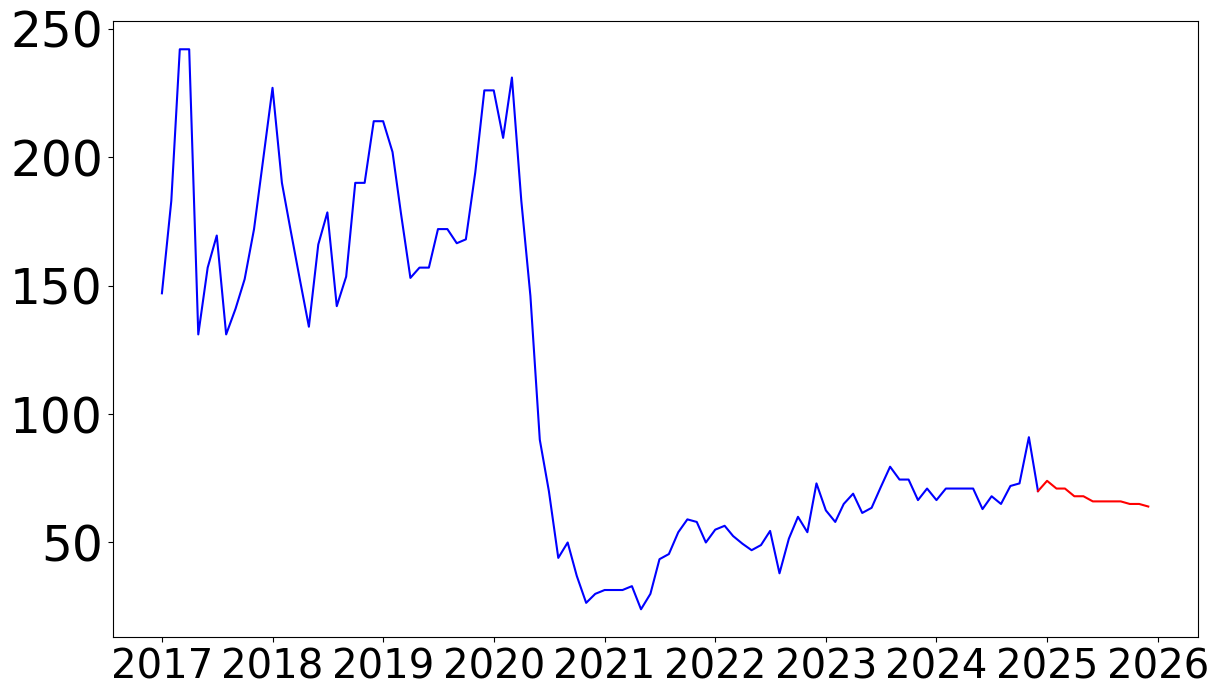

In [17]:
# Prediksi 12 bulan ke depan menggunakan sliding window
def predict_future(model, last_input, months=12):
    future_predictions = []
    current_input = last_input.copy()

    for _ in range(months):
        prediction = model.predict(current_input.reshape((1, timestep, 1)))
        future_predictions.append(prediction[0, 0])
        
        # Geser input window dengan menambahkan prediksi terbaru
        current_input = np.roll(current_input, -1)
        current_input[-1] = prediction[0, 0]

    return np.array(future_predictions).reshape(-1, 1)

# Gunakan data terakhir sebagai input awal
last_input = X_scaled[-timestep:]
future_preds_scaled = predict_future(model_cnn_gru, last_input, months=12)

# Cek nilai sebelum inverse transform
print("Prediksi dalam skala normalisasi:")
print(future_preds_scaled)

# Konversi kembali ke skala asli
future_preds = scaler.inverse_transform(future_preds_scaled)

# Konversi kembali ke skala asli dan ubah ke bilangan bulat
future_preds = scaler.inverse_transform(future_preds_scaled).astype(int)

# Cek nilai setelah inverse transform
print("Prediksi dalam skala asli:")
print(future_preds)

# Buat label bulan untuk prediksi
future_dates = pd.date_range(start=buku_600_copy['Bulan'].values[-1], periods=12, freq='M')

# Simpan hasil prediksi dalam DataFrame untuk analisis lebih lanjut
predictions_df = pd.DataFrame({'Bulan': future_dates, 'Prediksi': future_preds.flatten()})
print("Hasil prediksi dalam DataFrame:")
print(predictions_df)

# Gabungkan data aktual dan prediksi
combined_dates = np.concatenate([buku_600_copy['Bulan'].values, future_dates])
combined_values = np.concatenate([buku_600_copy['Jumlah_buku_dipinjam'].values, future_preds.flatten()])

# Visualisasi hasil prediksi dengan satu garis tetapi warna berbeda
plt.figure(figsize=(14, 8))

# Plot data aktual dengan warna biru
plt.plot(combined_dates[:len(buku_600_copy)], combined_values[:len(buku_600_copy)], color='blue', label='Actual Data')

# Plot data prediksi dengan warna merah (melanjutkan garis sebelumnya)
plt.plot(combined_dates[len(buku_600_copy)-1:], combined_values[len(buku_600_copy)-1:], color='red', label='CNN-GRU Forecast')
plt.xticks(fontsize=29)
plt.yticks(fontsize=35)
plt.show()